In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ..

/Users/purzelrakete/src/github.com/feldberlin/wavenet


In [87]:
import os

import numpy as np
import torch
import librosa
from torch.nn import functional as F
import matplotlib.pyplot as plt
import librosa.display
import IPython.display as ipd

from wavenet import model, train, sample, audio, datasets, utils, viz, debug

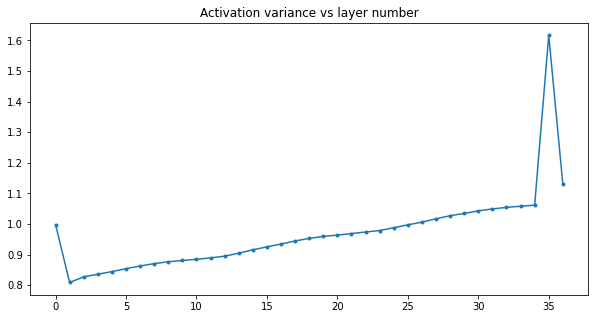

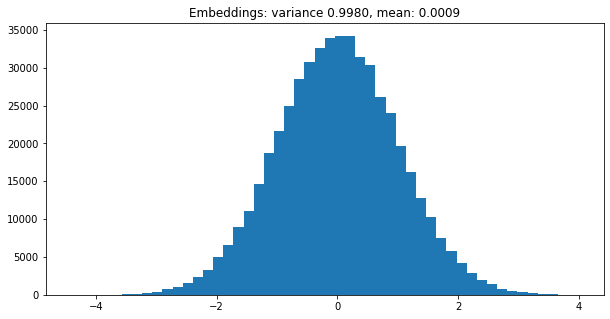

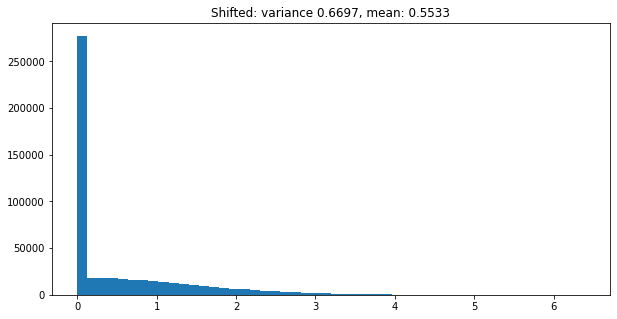

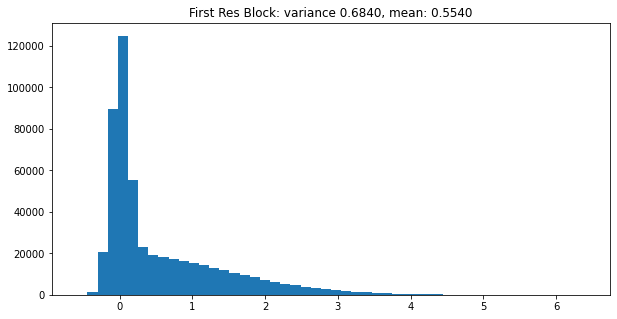

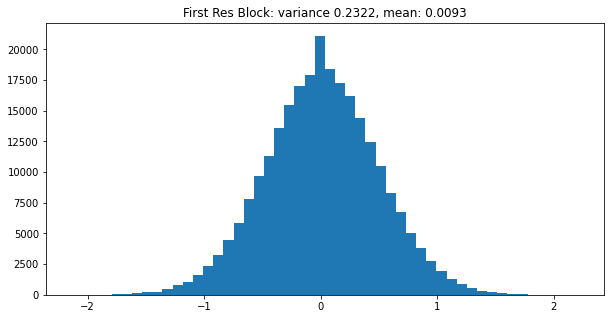

In [310]:
p = model.HParams(embed_inputs=True, mixed_precision=False)
m = model.Wavenet(p)
# debug.summarize(m)

# capture activations
memo = {}
debug.activations(m, memo)
x = torch.randint(p.n_classes, (10, p.n_audio_chans, 100), dtype=torch.long)
_ = m(x, x)

# activation functions may be missing. add them back in
plt.figure(figsize=(10, 5))
plt.title(f'Activation variance vs layer number')
xs = [
    res
    for k, (res, *_) 
    in memo.items()
]

# add in relus where they are not in the forward function
for i in [1, -1, -2]:
    xs[i] = F.relu(xs[i])
    
xs = [
    x.std().item()
    for x
    in xs
]
    
# plot the results
# xs = xs[:5]
plt.plot(range(len(xs)), xs, marker='.')

def fn(title, layer_index, activation=lambda x: x):
    _, activations = list(memo.items())[layer_index]
    if type(activations) == torch.Tensor:
        activations = [activations]
    for x in list(activations):
        x = x.detach().numpy().flatten()
        x = activation(torch.from_numpy(x)).numpy()
        plt.figure(figsize=(10, 5))
        plt.title(f"{title}: variance {str(x.var())[:6]}, mean: {str(x.mean())[:6]}")
        plt.hist(x, 50)
        plt.show()
        plt.close()
        
fn('Embeddings', 0)
fn('Shifted', 1, F.relu)
fn('First Res Block', 2)

In [203]:
import math

def dims(c):
    k, *_ = c.kernel_size
    c_out, c_in, *_ = c.weight.shape
    return c_out, c_in, k

    
N, C, W = 1, 512, 1_000
x = torch.randn(N, C, W)

layer = model.ResBlock(1, p)
with torch.no_grad():
    
    # conv
    c_out, c_in, k = dims(layer.conv)
    layer.conv.weight.normal_(0, math.sqrt(2 / (k * c_in)))
    layer.conv.bias.zero_()

    # res1x1
    c_out, c_in, k = dims(layer.res1x1)
    layer.res1x1.weight.normal_(0, math.sqrt(1 / (16 * k * c_in))) 
    layer.res1x1.bias.zero_()

    # skip1x1
    c_out, c_in, k = dims(layer.skip1x1)
    layer.skip1x1.weight.normal_(0, math.sqrt(1 / (k * c_in)))
    layer.skip1x1.bias.zero_()

    # compute
    res, skip = layer(x)
    
x = x.detach().numpy().flatten()
res = res.detach().numpy().flatten()
skip = skip.detach().numpy().flatten()

print(res.std(), res.std())
print(skip.std(), skip.std())

1.0290304 1.0290304
1.0086982 1.0086982


[]

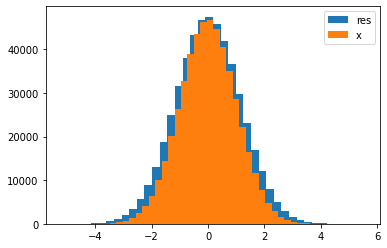

In [100]:
plt.hist(res, 40, label='res')
plt.hist(x, 40, label='x')

plt.legend();
plt.plot()

[]

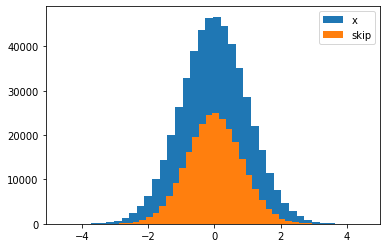

In [101]:
plt.hist(x, 40, label='x')
plt.hist(skip, 40, label='skip')
plt.legend();
plt.plot()

In [287]:
import math

def dims(c):
    k, *_ = c.kernel_size
    c_out, c_in, *_ = c.weight.shape
    return c_out, c_in, k

    
N, C, W = 100, 512, 1_000
x = torch.randn(N, C, W)

layer = model.ShiftedCausal1d(C, C, 1)
# layer = torch.nn.Conv1d(C, C, 2)
with torch.no_grad():
    c_out, c_in, k = dims(layer)
    layer.weight.normal_(0, math.sqrt(2 / (k * c_in)))
    layer.bias.zero_()
    y = F.relu(layer(x))

In [288]:
x.shape, y.shape

(torch.Size([100, 512, 1000]), torch.Size([100, 512, 1000]))

In [289]:
x.mean(), x.std()

(tensor(-7.4291e-05), tensor(0.9999))

In [290]:
y.mean(), y.std()

(tensor(0.5625), tensor(0.8243))

[]

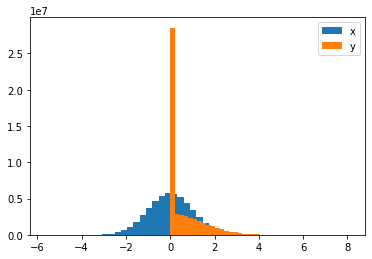

In [291]:
plt.hist(x.flatten().numpy(), 40, label='x')
plt.hist(y.flatten().numpy(), 40, label='y')
plt.legend();
plt.plot()

In [307]:
import math

def dims(c):
    k, *_ = c.kernel_size
    c_out, c_in, *_ = c.weight.shape
    return c_out, c_in, k

    
N, C, W = 100, 512, 1_000
# x = y # torch.randn(N, C, W)

layer = model.Causal1d(C, 2 * C, 1)
with torch.no_grad():
    c_out, c_in, k = dims(layer)
    layer.weight.normal_(0, math.sqrt(3 / (k * c_in)))
    layer.bias.zero_()
    y = F.glu(layer(x), dim=1)

In [308]:
y.mean(), y.std()

(tensor(0.0081), tensor(1.0098))

[]

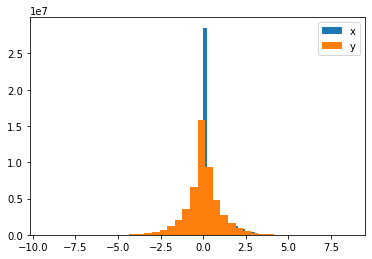

In [309]:
plt.hist(x.flatten().numpy(), 40, label='x')
plt.hist(y.flatten().numpy(), 40, label='y')
plt.legend();
plt.plot()